# $k$-Nearest Neighbors, Curse of Dimensionality, and Naive Bayes


## Learning Outcomes

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/jupyter_notebooks/09-Classification-II-kNN.ipynb)

In [5]:
#| echo: false
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mp
import sklearn

from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as datasets
import sklearn.metrics as metrics

# Colour-blind-safe (Okabe-Ito) class colours, shared with lecture 13.
# The "bold" map colours points, the "light" map shades decision regions.
from slideUtilities import class_cmaps, OKABE_ITO
cmap2_bold, cmap2_light = class_cmaps(2)   # two-class plots: orange, sky blue
cmap3_bold, cmap3_light = class_cmaps(3)   # three-class plots: + bluish green

In this lecture we introduce a second classification technique, $k$-Nearest Neighbors, and a third, Naive Bayes. After it, and the in-class activity, you will be able to

1. Explain what $k$-NN does at training time and at test time, say why it is *nonparametric*, and predict its output by hand from a table of distances.
2. Choose $k$ on held-out validation data as the bias--variance knob, reading the error bars over repeated splits honestly.
3. Quantify the **curse of dimensionality** -- empty bins, the outer-shell fraction $1-(1-\epsilon)^d$, distance concentration -- and explain what it does to the word "nearest".
4. Evaluate a classifier beyond a single accuracy number: read a confusion matrix and compute precision and recall for the class that matters.
5. Compute Naive Bayes by hand -- priors, per-feature conditionals, the zero-count veto and Laplace smoothing -- and explain why it dodges the curse that defeats $k$-NN.


## $k$-Nearest Neighbors

> When I see a bird that walks like a duck and swims like a duck and quacks like a duck, I call that bird a duck.

--James Whitcomb Riley (1849 - 1916)

![](figs/L15-duck.jpg)


Like any classifier, $k$-Nearest Neighbors is trained by providing it a set of labeled data.

However, at training time, the classifier does very little. It just stores away the training data.

## Example: Training Points - 2 Classes

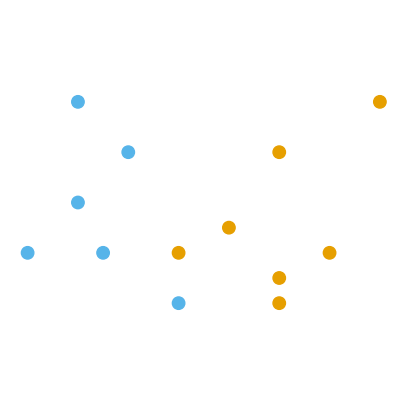

In [6]:
#| fig-align: center
plt.figure(figsize=(5, 5))
demo_y = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
demo_X = np.array([[-3,1], [-2, 4], [-2, 2], [-1.5, 1], [-1, 3], [0, 0], [1, 1.5], [2, 0.5], [2, 3], [2, 0], [3, 1], [4, 4], [0, 1]])
test_X = np.array([-0.3, 0.7])
#
plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap2_bold, s=80)
plt.axis('equal')
plt.axis('off')
plt.show()

Label 0 is drawn in orange, label 1 in sky blue.

---

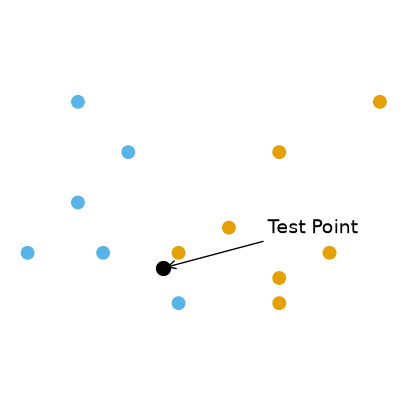

In [7]:
#| fig-align: center
plt.figure(figsize=(5, 5))
plt.scatter(demo_X[:, 0], demo_X[:, 1], c=demo_y, cmap=cmap2_bold, s=80)
plt.plot(test_X[0], test_X[1], 'ok', markersize=10)
plt.annotate('Test Point', test_X, [75, 25],
             textcoords = 'offset points', fontsize = 14,
             arrowprops = {'arrowstyle': '->'})
plt.axis('equal')
plt.axis('off')
plt.show()

At test time, simply

* "look at" the $k$ points in the training set that are nearest to the test input $\mathbf{x}$, and
* make a decision based on the labels on those points, e.g. majority vote

## 1-Nearest Neighbor

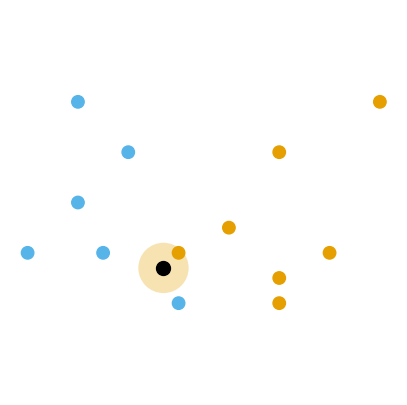

In [8]:
#| fig-align: center
plt.figure(figsize=(5, 5))
plt.scatter(demo_X[:, 0], demo_X[:, 1], c=demo_y, cmap=cmap2_bold, s=80)
plt.plot(test_X[0], test_X[1], 'ok', markersize=10)
ax=plt.gcf().gca()
circle = mp.patches.Circle(test_X, 0.5, facecolor = OKABE_ITO[0], alpha = 0.3)
plt.axis('equal')
plt.axis('off')
ax.add_artist(circle)
plt.show()

The nearest point is orange, so 1-NN predicts **orange** (label 0).

## 2-Nearest Neighbors

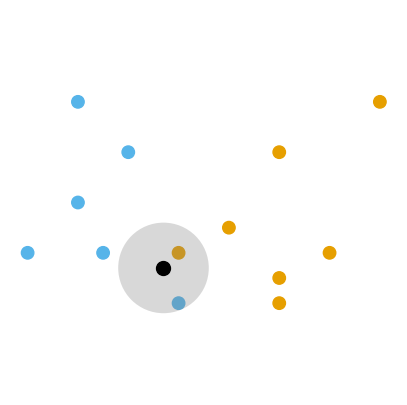

In [9]:
#| fig-align: center
plt.figure(figsize=(5, 5))
plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap2_bold, s=80)
plt.plot(test_X[0], test_X[1], 'ok', markersize=10)
ax=plt.gcf().gca()
circle = mp.patches.Circle(test_X, 0.9, facecolor = 'gray', alpha = 0.3)
plt.axis('equal')
plt.axis('off')
ax.add_artist(circle)
plt.show()

One orange and one sky-blue neighbour: a **tie**. The majority vote is undefined.

## 3-Nearest Neighbors

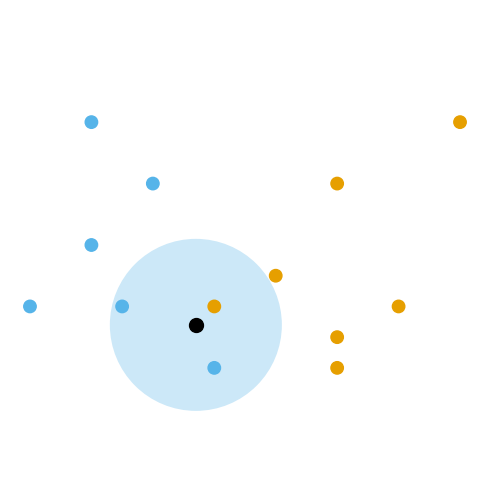

In [10]:
#| fig-align: center
plt.figure(figsize=(5, 5))
ax=plt.gcf().gca()
circle = mp.patches.Circle(test_X, 1.4, facecolor = OKABE_ITO[1], alpha = 0.3)
ax.add_artist(circle)
plt.scatter(demo_X[:,0], demo_X[:,1], c=demo_y, cmap=cmap2_bold, s=80)
plt.plot(test_X[0], test_X[1], 'ok', markersize=10)
plt.axis('equal')
plt.axis('off')
plt.tight_layout()
plt.show()

Two sky-blue neighbours against one orange: 3-NN predicts **sky blue** (label 1).

## The Same Thing as a Distance Table

The pictures hide the arithmetic. Here are the five training points nearest to the test point $\mathbf{x} = (-0.3, 0.7)$, sorted by Euclidean distance:

In [11]:
dist = np.linalg.norm(demo_X - test_X, axis=1)
order = np.argsort(dist)[:5]
colour = np.array(['orange', 'sky blue'])
pd.DataFrame({'x1': demo_X[order, 0], 'x2': demo_X[order, 1],
              'label': demo_y[order], 'colour': colour[demo_y[order]],
              'distance': dist[order].round(2)},
             index=pd.Index(range(1, 6), name='rank'))

,x1,x2,label,colour,distance
rank,,,,,
1,0.0,1.0,0,orange,0.42
2,0.0,0.0,1,sky blue,0.76
3,-1.5,1.0,1,sky blue,1.24
4,1.0,1.5,0,orange,1.53
5,-2.0,2.0,1,sky blue,2.14


* $k = 1$: $\{0\}$ $\rightarrow$ **orange**.
* $k = 2$: $\{0, 1\}$ $\rightarrow$ a **tie**.
* $k = 3$: $\{0, 1, 1\}$ $\rightarrow$ **sky blue**.
* $k = 5$: $\{0, 1, 1, 0, 1\}$ $\rightarrow$ **sky blue**, but now by 3 votes to 2.


This is all a $k$-NN classifier ever does: sort the distances, take the top $k$, count the labels.


## Hard vs. Soft Classification

$k$-Nearest Neighbors can do either __hard__ or __soft__ classification.

* As a **hard classifier**, it returns the majority vote of the labels on the $k$ Nearest Neighbors.

* As a **soft classifier**, it returns the fraction of points in the neighborhood with label $c$:

$$
p(y = c \mid \mathbf{x}, k) = \frac{\text{number of the } k \text{ neighbours with label } c}{k}.
$$

For the test point above, $p(y = 1 \mid \mathbf{x}, 3) = 2/3$ and $p(y = 1 \mid \mathbf{x}, 5) = 3/5$.


**Ties.** With two classes and an even $k$, the vote can split evenly -- the $k = 2$ picture above is one such case. The usual fix is to use an **odd** $k$ for binary problems. (If you don't, `scikit-learn` silently breaks the tie in favour of the smaller label, which is not a decision you want made for you.)


## Parametric vs. Nonparametric Models

Notice what $k$-NN stores: the entire training set. There is no fixed set of parameters that summarise the data -- the data *is* the model. That makes $k$-NN our first **nonparametric** model.

**Parametric models**

* have a __fixed number__ of parameters, however much training data there is
* are (usually) fast to apply once trained
* make strong assumptions about the data's distribution
* examples: linear and logistic regression (lectures 10--11), Naive Bayes (today)

**Nonparametric models**

* have a number of "parameters" that __grows with the training data__
* are more flexible
* can be slow or memory-hungry on large datasets
* examples: $k$-NN (today), decision trees and random forests (lecture 08)


## Model Selection for $k$-NN

* Each value of $k$ results in a different "model".

* The complexity of the resulting model is therefore controlled by the hyperparameter $k$.

* We will want to select $k$ using held-out data to avoid over-fitting.


## Varying $k$

Consider this dataset where items fall into three classes:


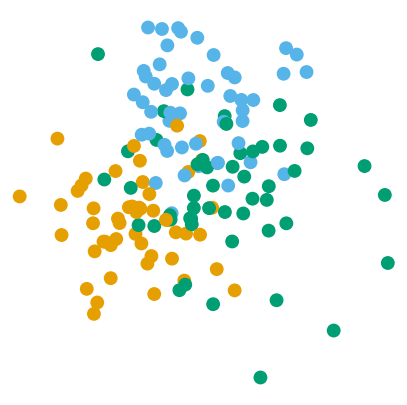

In [12]:
import sklearn.datasets as sk_data
X, y = sk_data.make_blobs(n_samples=150, 
                          centers=[[-2, 0],[1, 5], [2.5, 1.5]],
                          cluster_std = [2, 2, 3],
                          n_features=2,
                          center_box=(-10.0, 10.0),random_state=0)
plt.figure(figsize = (5, 5))
plt.axis('equal')
plt.axis('off')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = cmap3_bold, s = 80)
plt.show()

* Let's observe how the complexity of the resulting model changes as we vary $k$.

* We'll do this by plotting the __decision regions__.   These show how the method would classify each potential test point in the space.


---

In [13]:
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
h = .1  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

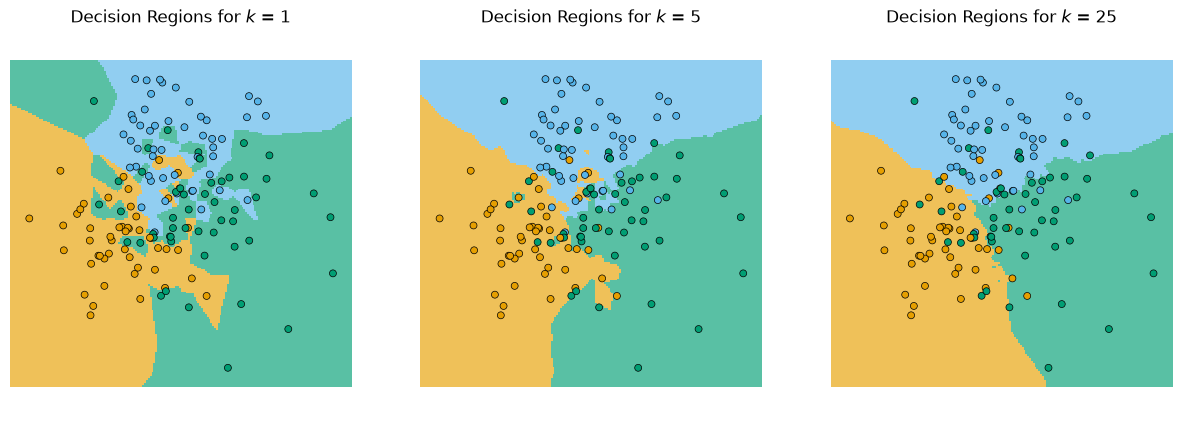

In [14]:
f, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([1, 5, 25]):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axs[i].pcolormesh(xx, yy, Z, cmap = cmap3_light, shading = 'auto')
    # overlay the training points that produced these regions
    axs[i].scatter(X[:, 0], X[:, 1], c = y, cmap = cmap3_bold, s = 25, edgecolors = 'k', linewidths = 0.5)
    axs[i].axis('equal')
    axs[i].axis('off')
    axs[i].set_title(f'Decision Regions for $k$ = {k}')
plt.show()

With $k = 1$ every training point owns a little island, so the boundary wraps around each stray point. Increasing $k$ smooths the boundary: the stray points are out-voted by their neighbours.

Smoother boundaries are more likely to generalize well -- but not always, as we will see.

## Challenges for $k$-NN

Working with a $k$-NN classifier can involve some challenges.

1. The computational cost of classification grows linearly with the size of the training data. Note that the training step is trivial, but the classification step can be prohibitively expensive.

2. Euclidean distance is the most common distance function used in $k$-NN so data scaling is important. As previously
   [discussed](03-Clustering-I-kmeans.qmd#feature-scales), features
   should be scaled to prevent distance measures from being dominated by a potentially small subset of features.

3. The __curse of dimensionality.__ If the training data lives in a high dimensional space, Euclidean distance measures become less effective.


This last point is subtle but important, so we will now look at the curse of dimensionality more closely.


# The Curse of Dimensionality

## The Curse of Dimensionality

![](figs/L15-curse-frankenstein-edited.jpeg)


<br><br>
The **curse of dimensionality** is a somewhat tongue-in-cheek term for serious problems that arise when we use geometric algorithms in high dimensions.


There are various aspects of the curse that affect $k$-NN.

The phrase `curse of dimensionality' was coined by the mathematician Richard Bellman in 1957 in his book _Dynamic Programming._



## Points are far apart in high D

* $k$-NN relies on there being one or more "close" points to the test point $x$.   

* In other words, we need the training data to be relatively dense, so there are "close" points everywhere.

* Unfortunately, the amount of space we work in grows exponentially with the dimension $d$.



![10x10 grid with $10^2$ bins](figs/L15-10x10-grid.png)  

![10x10x10 grid with $10^3$ bins](figs/L15-10x10x10-grid.png)


* Imagine we have 10,000 (e.g. $10^4$) data points each with 40 features (e.g. $d = 40$).
* Consider quantizing each dimension into 10 bins.
* So in 40-D we have $10^{40}$ possible bins.
* On average, we will only have 1 data point per $10^{36}$ bins. Most will be empty!!
* So the amount of data we need to maintain a given density also grows exponentially with dimension $d$.




One very intuitive way to think about it is this.

>In order for two points to be close in $\mathbb{R}^d$, they must be close in __each__ of the $d$ dimensions.
>As the number of dimensions grows, it becomes harder and harder for a pair of points to be close in __each__ dimension.

## Distances concentrate in high dimensions

Being "far apart" is only half the story. The other half is that in high dimensions **all pairs of points become nearly equally far apart**, so "nearest" stops singling anything out.

Let's measure this. For 1000 standard-normal points in $d$ dimensions, we compute every pairwise distance and look at the ratio of the **largest** to the **smallest**:

In [15]:
from scipy.spatial.distance import pdist

rng = np.random.default_rng(0)
n_data = 1000
dims = [2, 3, 10, 30, 100, 300, 1000]
metrics_to_try = {'Euclidean': 'euclidean', 'Manhattan': 'cityblock', 'Cosine': 'cosine'}

ratio = {name: [] for name in metrics_to_try}
summary = []
for d in dims:
    x = rng.normal(size=(n_data, d))
    for name, metric in metrics_to_try.items():
        dists = pdist(x, metric)          # all n(n-1)/2 pairwise distances
        ratio[name].append(dists.max() / dists.min())
        if name == 'Euclidean':
            summary.append((d, dists.mean(), dists.std() / dists.mean()))

`scipy.spatial.distance.pdist` returns the $n(n-1)/2$ distances between distinct pairs as a flat vector -- the same computation as a double `for` loop, but fast.


## Largest / smallest distance ratio

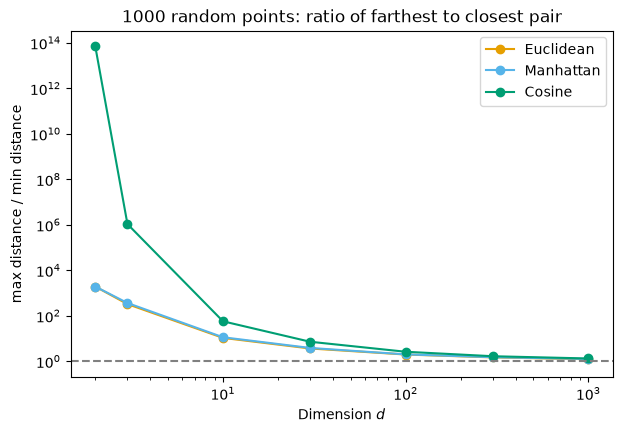

In [16]:
#| fig-align: center
plt.figure(figsize=(7, 4.5))
for name, colour in zip(ratio, OKABE_ITO):
    plt.plot(dims, ratio[name], 'o-', color=colour, label=name)
plt.axhline(1, linestyle='--', color='gray')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Dimension $d$')
plt.ylabel('max distance / min distance')
plt.title('1000 random points: ratio of farthest to closest pair')
plt.legend()
plt.show()

A ratio of 1 (dashed) would mean every pair is at the *same* distance. All three metrics head toward it. Manhattan and cosine distance stay a little further from 1 than Euclidean, which is one reason they are sometimes preferred in high dimensions -- but none escapes the trend.

## Distances do not shrink -- they concentrate

The mean Euclidean distance between random points actually *grows* with $d$ (roughly like $\sqrt{2d}$ for standard normals). What collapses is the **spread** around that mean:

In [17]:
pd.DataFrame(summary, columns=['d', 'mean distance', 'std / mean']).round(3).set_index('d')

,mean distance,std / mean
d,,
2,1.775,0.521
3,2.247,0.412
10,4.366,0.227
30,7.705,0.129
100,14.108,0.069
300,24.524,0.040
1000,44.661,0.022


Relative to the typical distance, the closest point is barely closer than a random one. That is what "nearest" means in 1000 dimensions.


## Most of a ball is near its surface

Here is a geometric way to see the same concentration. Compare a ball of radius $1$ with the slightly smaller ball of radius $1-\epsilon$ inside it:

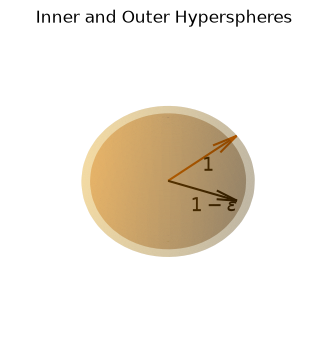

In [18]:
#| fig-align: center
ax = plt.figure(figsize = (4, 4)).add_subplot(projection = '3d')
# coordinates of sphere surface
u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
#
ax.plot_surface(x, y, z, color=OKABE_ITO[0], alpha = 0.2)
s3 = 1/np.sqrt(3)
ax.quiver(0, 0, 0, s3, s3, s3, color = OKABE_ITO[5])
ax.text(s3/2, s3/2, s3/2-0.2, '1', size = 14)
#
eps = 0.9
#
ax.plot_surface(eps * x, eps * y, eps * z, color=OKABE_ITO[5], alpha = 0.2)
ax.quiver(0, 0, 0, eps, 0, 0, color = 'k')
ax.text(1/2-0.2, 0, -0.4, r'$1-\epsilon$', size = 14)
ax.set_axis_off()
plt.title('Inner and Outer Hyperspheres')
plt.show()

In 3-D the shell between them is thin. In high dimensions it is almost the whole ball.

## Fraction of points in outer shell

What is the fraction $f_d$ of all the points that are within a unit distance, but __not__ within a distance of $1-\epsilon$?

The volume of a ball of radius $R$ in $d$ dimensions is $K_d \times R^d$ for a constant $K_d$ that depends only on $d$ ($K_2 = \pi$, $K_3 = \tfrac{4}{3}\pi$; the general formula is in the note below). The $R^d$ is all we need.

---

Then for $R=1$ and $R=1-\epsilon$ we have:

$$
\begin{align*}
f_d &= \frac{\text{Volume of Shell}}{\text{Volume of unit hypersphere}} \\
&= \frac{K_d\times(1)^d - K_d\times(1-\epsilon)^d}{K_d\times(1)^d} \\
&= 1 - (1-\epsilon)^d
\end{align*}
$$

Observe that $(1-\epsilon)^d$ goes to 0 as $d \rightarrow \infty$ and $f_d\rightarrow 1$ as $d \rightarrow \infty$.

This means that as $d\rightarrow \infty$, all of the points that are __within__ 1 unit of our location, are almost __exactly__ 1 unit from our location.


## The shell fraction in numbers

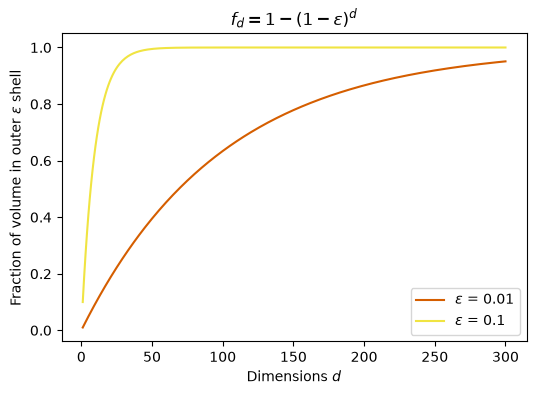

In [19]:
#| fig-align: center
d_vals = np.arange(1, 301)
plt.figure(figsize = (6, 4))
for eps, colour in zip([0.01, 0.1], [OKABE_ITO[5], OKABE_ITO[3]]):
    plt.plot(d_vals, 1 - (1 - eps) ** d_vals, color=colour, label=fr'$\epsilon$ = {eps}')
plt.xlabel('Dimensions $d$')
plt.ylabel(r'Fraction of volume in outer $\epsilon$ shell')
plt.title(r'$f_d = 1 - (1-\epsilon)^d$')
plt.legend(loc = 'lower right')
plt.show()

With $\epsilon = 0.1$ the shell holds 96% of the ball by $d = 30$; with $\epsilon = 0.01$ it holds 95% by $d = 300$.

**Going deeper: the volume of a hypersphere**


The constant $K_d$ comes from the [general formula](https://en.wikipedia.org/wiki/Volume_of_an_n-ball#Formulas)
for the volume of a ball of radius $R$ in $d$ dimensions,

$$
V_d(R) = \frac{\pi^{d/2}}{\Gamma\bigl(\tfrac d2 + 1\bigr)}R^d,
$$

where $\Gamma$ is Euler's gamma function. For a positive integer $n$, $\Gamma(n) = (n-1)!$, so when $d$ is even $\Gamma(\tfrac d2 + 1) = (\tfrac d2)!$; for odd $d$ there is a closed form involving $\sqrt{\pi}$.

In [20]:
import scipy.special as sci

def volume_of_hypersphere(radius, dimensions):
    return (np.pi ** (dimensions / 2)) / sci.gamma(dimensions / 2 + 1) * radius ** dimensions

vols = [volume_of_hypersphere(1.0, d) for d in range(1, 21)]

The volume of the *unit* ball peaks at $d = 5$ and then shrinks toward zero, and the fraction of the enclosing cube $[-1, 1]^d$ that the ball occupies vanishes even faster -- almost all of the cube is in its $2^d$ corners.

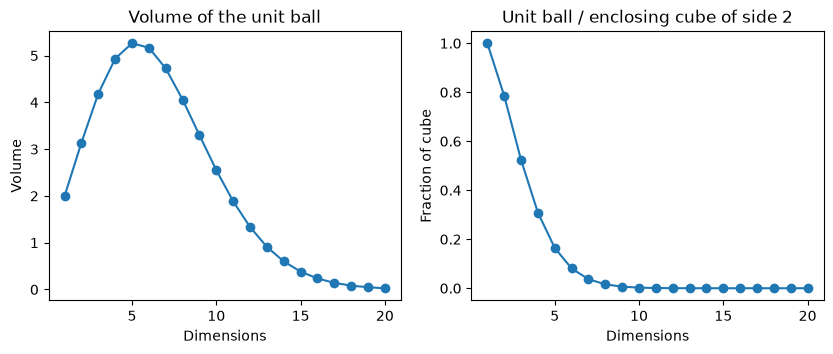

In [21]:
#| fig-align: center
fig, axs = plt.subplots(1, 2, figsize = (10, 3.5))
axs[0].plot(range(1, 21), vols, 'o-')
axs[0].set_xlabel('Dimensions')
axs[0].set_ylabel('Volume')
axs[0].set_title('Volume of the unit ball')
axs[1].plot(range(1, 21), [v / 2 ** d for v, d in zip(vols, range(1, 21))], 'o-')
axs[1].set_xlabel('Dimensions')
axs[1].set_ylabel('Fraction of cube')
axs[1].set_title('Unit ball / enclosing cube of side 2')
plt.show()

For a fascinating exploration of the properties of unit spheres in high dimension,
see [An Adventure in the Nth Dimension](https://www.americanscientist.org/article/an-adventure-in-the-nth-dimension)
by Brian Hayes in _American Scientist._


## Curse of Dimensionality Example

The following example is based on _Data Science from Scratch,_ Joel Grus, Second Edition, Chapter 12.


Here's another example, now with points spread *uniformly* rather than normally.

We create 1000 points, scattered at random within the unit cube in $d$ dimensions, and add one dimension at a time.

We will look at two quantities as we vary $d$.

* The __minimum__ distance between any two points.
* The __average__ distance between any two points.

---

In [22]:
rng = np.random.default_rng(0)   # seeded, so the figure is reproducible

nsamples = 1000
unif_X = rng.uniform(0, 1, nsamples).reshape(-1, 1)
dists = pdist(unif_X)
mean_dists = [np.mean(dists)]
min_dists = [np.min(dists)]
for d in range(2, 101):
    unif_X = np.column_stack([unif_X, rng.uniform(0, 1, nsamples)])
    dists = pdist(unif_X)
    mean_dists.append(np.mean(dists))
    min_dists.append(np.min(dists))

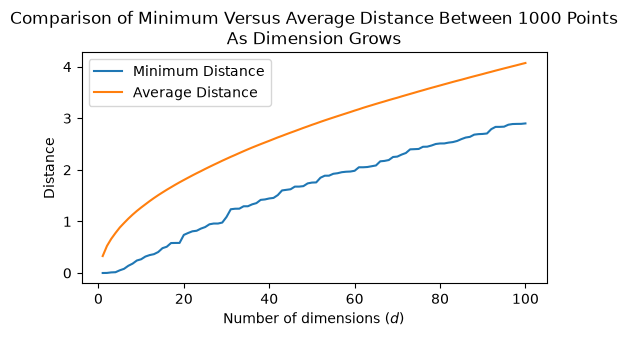

In [23]:
#| fig-align: center
plt.figure(figsize = (6, 3))
plt.plot(range(1, 101), min_dists, label = "Minimum Distance")
plt.plot(range(1, 101), mean_dists, label = "Average Distance")
plt.xlabel(r'Number of dimensions ($d$)')
plt.ylabel('Distance')
plt.legend(loc = 'best')
plt.title(f'Comparison of Minimum Versus Average Distance Between {nsamples} Points\nAs Dimension Grows')
plt.show()

The average distance between points grows. However we also observe that the minimum distance between points grows at a similar rate.

---

Let's look at the ratio between the minimum distance between points and the average distance between points.

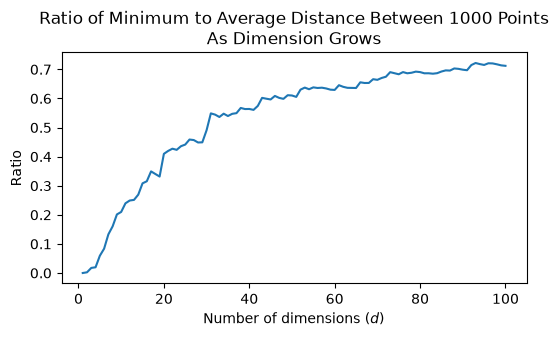

In [24]:
#| fig-align: center
plt.figure(figsize = (6, 3))
plt.plot(range(1, 101), [a/b for a, b in zip(min_dists, mean_dists)])
plt.xlabel(r'Number of dimensions ($d$)')
plt.ylabel('Ratio')
plt.title(f'Ratio of Minimum to Average Distance Between {nsamples} Points\nAs Dimension Grows')
plt.show()

This shows that, for any test point $x$, the distance to the __closest__ point to $x$, gets closer and closer to the __average__ distance between points.

If we used a point at the average distance for classifying $x$ we'd get a very poor classifier.

##  Implications of the Curse

For $k$-NN, the Curse of Dimensionality means that in high dimensions most points are nearly the same distance from the test point.

This makes $k$-NN ineffective. It cannot reliably tell which are the $k$ nearest neighbors and its performance degrades as $d$ increases.

__What Can be Done?__


The problem is that you simply cannot have enough data to do a good job using $k$-NN in high dimensions.


Alternative approaches to mitigate this issue

- Use a different dissimilarity metric
    - For example cosine distance behaves a little better, but you will have to decide if it is a good distance function for your problem.
- __Reduce__ the dimension of your data.
    - We will discuss dimensionality reduction techniques in lectures [SVD I](12-SVD-Low-Rank.qmd) and [SVD II](13-Dimensionality-Reduction-PCA-tSNE.qmd).


## More on Model Selection

Recall that each value of $k$ provides a different model.

To better understand __model selection__, we need a way to evaluate our different models.


How do we evaluate a classifier?


# Binary classification

In the simple case of a binary classifier, we call

* one class the __Positive__ class -- usually the one we are trying to detect -- and
* the other class the __Negative__ class.

Which label is "Positive" is a convention *we* choose, and it has to be stated: in the two-circles example below, **label 0 (orange) is the Positive class** and label 1 (sky blue) is Negative.

The most basic measure of success for a classifier is __accuracy__:

* **Accuracy** is the fraction of test points that are correctly classified.

* Accuracy is important, however it may not convey enough useful information.
* For example, let's say we have a dataset showing __class imbalance__, e.g., 90% of the data are the Positive class and 10% are the Negative class.
* For this dataset, consider a classifier that always predicts 'Positive'. 
* Its accuracy is 90%, but it is not an effective classifier.
 

## Precision and Recall


![](figs/L15-confusion-matrix.png)

A better way to measure the classifier's performance is using a Confusion Matrix.

Diagonal elements represent successes and off diagonals represent errors.


Using the confusion matrix we can define some more useful measures:

* __Recall__ - defined as the fraction of actual positives correctly classified
    * TP/(TP + FN)
* __Precision__ - defined as the fraction of classified positives correctly classified
    * TP/(TP + FP)

## Precision and Recall Illustration


![](figs/Precisionrecall.png)

![](figs/Precisionrecall2.png)


<!-- By Walber - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=36926283 -->

## Evaluating $k$- Nearest Neighbors


First we'll generate some synthetic data to work with.

In [25]:
X, y = datasets.make_circles(noise=.1, factor=.5, random_state=1)
print('Shape of data: {}'.format(X.shape))
print('Unique labels: {}'.format(np.unique(y)))

def plot_points(X, y, title='', ax=None):
    """Scatter two-class points: label 0 orange, label 1 sky blue."""
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap2_bold, vmin=0, vmax=1, s=80)
    ax.set_title(title)
    ax.axis('equal')
    ax.axis('off')
    return ax

Shape of data: (100, 2)
Unique labels: [0 1]


Here is what the data looks like.

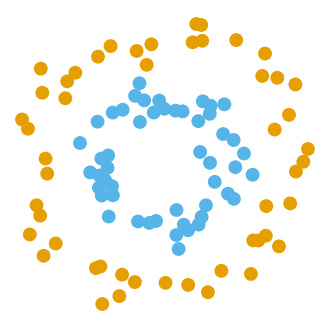

In [27]:
#| fig-align: center
plt.figure(figsize = (4, 4))
plot_points(X, y)
plt.show()

---

Recall that we always want to test on data separate from our training data.

For now, we will do something very simple: take the first 50 examples for training and the rest for testing.

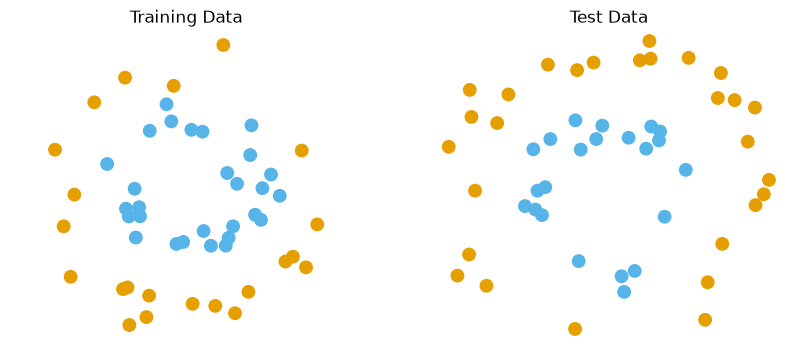

In [26]:
#| fig-align: center
X_train, y_train = X[:50], y[:50]
X_test, y_test = X[50:], y[50:]

fig, axs = plt.subplots(1, 2, figsize = (10, 4))
plot_points(X_train, y_train, 'Training Data', ax=axs[0])
plot_points(X_test, y_test, 'Test Data', ax=axs[1])
plt.show()

---

For our first example, we will classify the points (in the two classes) using a $k$-NN classifier.

We will specify that $k=5$, i.e., we will classify based on the majority vote of the 5 nearest neighbors.

In [28]:
k = 5
knn5 = KNeighborsClassifier(n_neighbors = k)

As we have seen previously, the `scikit-learn` `fit()` function corresponds to __training__ and the `predict()` function corresponds to __testing.__

In [29]:
knn5.fit(X_train,y_train)
print(f'Accuracy on test data: {knn5.score(X_test, y_test)}')

Accuracy on test data: 0.72


Accuracy of 72% sounds good -- but let's dig deeper.

## Confusion Matrix

Recall our convention: the orange points (label 0) are the Positive class and the sky-blue points (label 1) are Negative. We pass `labels=[0, 1]` so that the rows and columns come out in the order we name them:

In [30]:
y_pred_test = knn5.predict(X_test)
pd.DataFrame(metrics.confusion_matrix(y_test, y_pred_test, labels=[0, 1]),
             columns = ['Pred Pos (orange, 0)', 'Pred Neg (sky blue, 1)'],
             index = ['Actual Pos (orange, 0)', 'Actual Neg (sky blue, 1)'])

,"Pred Pos (orange, 0)","Pred Neg (sky blue, 1)"
"Actual Pos (orange, 0)",14,14
"Actual Neg (sky blue, 1)",0,22


Reading across the rows: every Negative point is classified correctly, but only 14 of the 28 Positive points are. Reading down the first column: every point the classifier *called* Positive really is Positive.

That is, its __precision__ is $14/(14+0) = 100\%$, but its __recall__ is only $14/(14+14) = 50\%$.

Let's visualize the results.

---

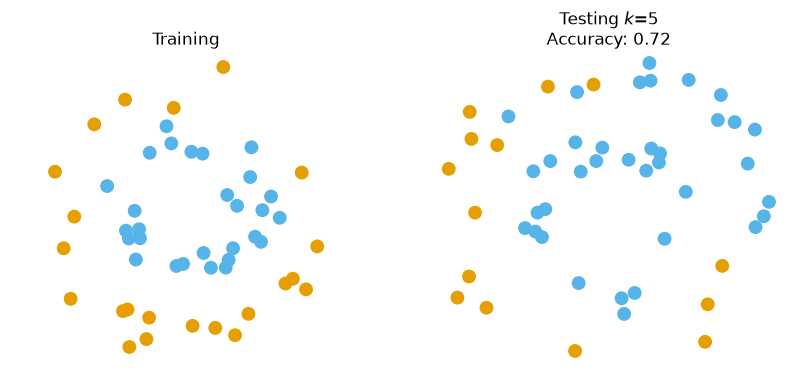

In [31]:
#| fig-align: center
fig, axs = plt.subplots(1, 2, figsize = (10, 4))
plot_points(X_train, y_train, 'Training', ax=axs[0])
plot_points(X_test, y_pred_test, f'Testing $k$={k}\nAccuracy: {knn5.score(X_test, y_test)}', ax=axs[1])
plt.show()

Indeed, the Positive (orange) points in the upper half of the test data are all classified incorrectly -- they come out sky blue.

---

Let's look at one of the points that the classifier got wrong.

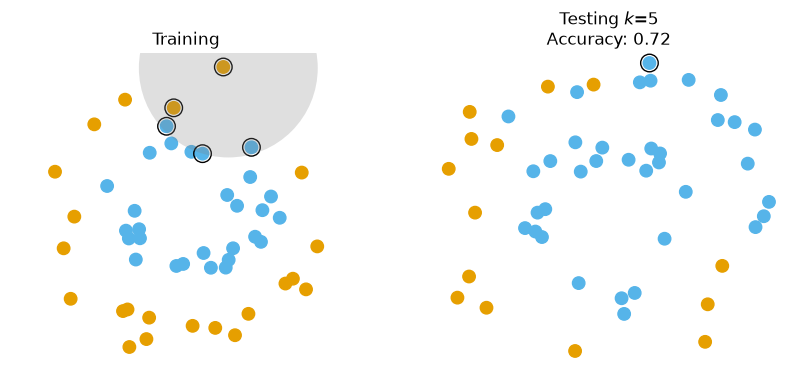

In [32]:
#| fig-align: center
def plot_neighborhood(knn, k, X_train, y_train, X_test, y_pred_test, test_point):
    """Left: training data with the k neighbours of one test point circled.
    Right: test predictions with that test point circled."""
    neighbors = knn.kneighbors([X_test[test_point]])[1][0]
    radius = np.max(np.linalg.norm(X_train[neighbors] - X_test[test_point], axis=1))

    fig, axs = plt.subplots(1, 2, figsize = (10, 4))
    plot_points(X_train, y_train, 'Training', ax=axs[0])
    axs[0].scatter(X_train[neighbors, 0], X_train[neighbors, 1],
                   facecolors='none', edgecolors='k', s=160)
    axs[0].add_artist(mp.patches.Circle(X_test[test_point], radius, facecolor='gray', alpha=0.25))

    plot_points(X_test, y_pred_test,
                f'Testing $k$={k}\nAccuracy: {knn.score(X_test, y_test)}', ax=axs[1])
    axs[1].scatter(X_test[test_point, 0], X_test[test_point, 1],
                   facecolors='none', edgecolors='k', s=160)
    plt.show()

test_point = np.argmax(X_test[:, 1])     # the top-most test point
plot_neighborhood(knn5, 5, X_train, y_train, X_test, y_pred_test, test_point)

Three of its five nearest training points are sky blue, so the vote goes against it.

---

For comparison purposes, let's try $k$ = 3.

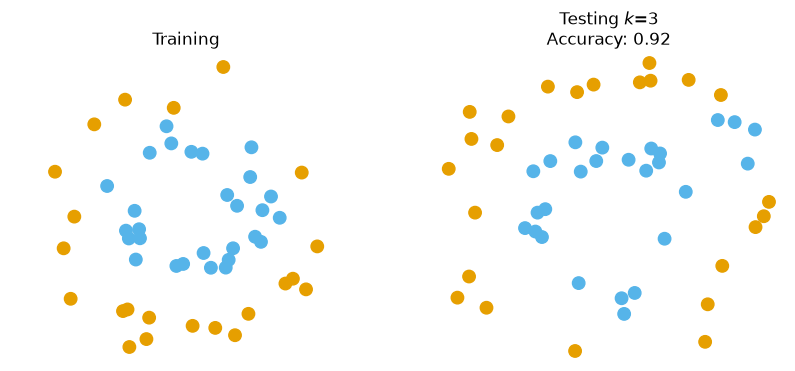

In [33]:
#| fig-align: center
k = 3
knn3 = KNeighborsClassifier(n_neighbors=k)
knn3.fit(X_train,y_train)
y_pred_test = knn3.predict(X_test)

fig, axs = plt.subplots(1, 2, figsize = (10, 4))
plot_points(X_train, y_train, 'Training', ax=axs[0])
plot_points(X_test, y_pred_test, f'Testing $k$={k}\nAccuracy: {knn3.score(X_test, y_test)}', ax=axs[1])
plt.show()

---

And let's look at the same individual point as before.

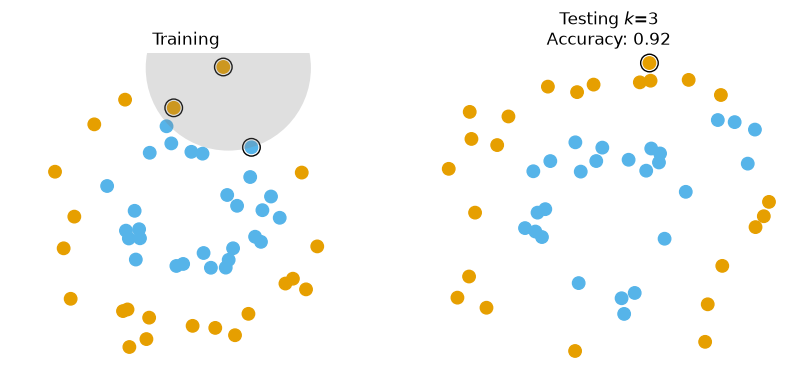

In [34]:
#| fig-align: center
plot_neighborhood(knn3, 3, X_train, y_train, X_test, y_pred_test, test_point)

## Choosing $k$ on Validation Data

So how confident can we be that the accuracy of 92% for $k = 3$ holds in general? Is $k = 3$ really better than $k = 5$, or did we get a lucky split?

What we really need to do is consider __many__ different random splits.

But first, a word about names. We are about to use the held-out half of the data to **choose** $k$. [Lecture 07](07-Generalization.qmd#wait-which-set-did-we-just-use-to-choose-k) named the roles: data held out from training to *choose* hyperparameters is the __validation set__; the __test set__ is touched once, at the very end, to report the final number. From here on the held-out split is called validation.


---

The protocol for choosing a hyperparameter is therefore:

1. Form a random train/validation split
2. Train the classifier on the training split
3. Score the classifier on the validation split
4. Accumulate statistics
5. Repeat from step 1 until enough statistics have been collected

-- and do all of this for each candidate value of $k$.

Because this is a binary problem we sweep **odd** $k$ only, so that no vote can tie.

---

In [35]:
import sklearn.model_selection as model_selection

nreps = 50
kvals = range(1, 16, 2)
acc = []
se = []
np.random.seed(4)
for k in kvals:
    val_rep = []
    train_rep = []
    for i in range(nreps):
        X_train, X_val, y_train, y_val = model_selection.train_test_split(X,
                                                                          y,
                                                                          test_size = 0.5)
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        train_rep.append(knn.score(X_train, y_train))
        val_rep.append(knn.score(X_val, y_val))
    acc.append([np.mean(val_rep), np.mean(train_rep)])
    se.append(np.std(val_rep) / np.sqrt(nreps))   # standard error of the mean
accy = np.array(acc)

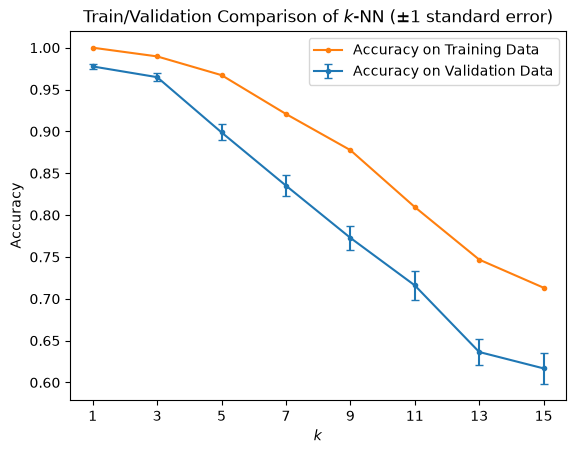

Best validation accuracy at k = 1: 0.978


In [36]:
#| fig-align: center
plt.errorbar(kvals, accy[:, 0], se, fmt = '.-', capsize = 3, label = 'Accuracy on Validation Data')
plt.plot(kvals, accy[:, 1], '.-', label = 'Accuracy on Training Data')
plt.xlabel(r'$k$')
plt.ylabel('Accuracy')
plt.xticks(kvals)
plt.title(r'Train/Validation Comparison of $k$-NN ($\pm 1$ standard error)')
plt.legend(loc = 'best')
plt.show()
print(f'Best validation accuracy at k = {kvals[np.argmax(accy[:, 0])]}: {np.max(accy[:, 0]):.3f}')

---

Based on validation accuracy, $k = 1$ is the best choice here, with $k = 3$ just behind and every $k \ge 5$ clearly worse.

* The **training** curve is useless for this decision: at $k = 1$ it is 100% by construction, because every training point is its own nearest neighbour.
* The **data** decide, not a preference for smooth boundaries. These two rings are cleanly separated with little label noise, so a very local model wins. On noisier data the validation curve would peak at a larger $k$.


Here is the __decision boundary__ for $k$-NN with $k = 1$.

In [37]:
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
plot_step = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                     np.arange(y_min, y_max, plot_step))

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


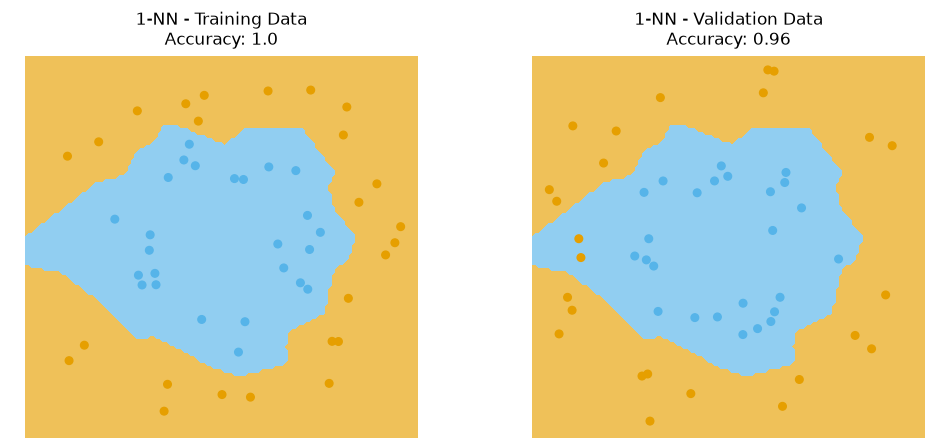

In [38]:
#| fig-align: center
np.random.seed(1)
X_train, X_val, y_train, y_val = model_selection.train_test_split(X, y, test_size = 0.5)

k = 1
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train, y_train)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize = (12, 5))
for ax, (XX, yy_, name) in zip(axs, [(X_train, y_train, 'Training'), (X_val, y_val, 'Validation')]):
    ax.contourf(xx, yy, Z, cmap=cmap2_light, vmin=0, vmax=1)
    ax.scatter(XX[:, 0], XX[:, 1], c=yy_, cmap=cmap2_bold, vmin=0, vmax=1, s=30)
    ax.axis('equal')
    ax.axis('off')
    ax.set_xlim((x_min, x_max))
    ax.set_ylim((y_min, y_max))
    ax.set_title(f'{k}-NN - {name} Data\nAccuracy: {knn.score(XX, yy_)}')
plt.show()

# Real Data

To explore a few more issues, we'll now turn to some famous datasets that have been extensively studied in the past.

## The Iris Dataset

The Iris dataset is a famous dataset used by Ronald Fisher in a classic 1936 paper on classification.

![R. A. Fisher](figs/R._A._Fisher.png)

---

Quoting from Wikipedia:

>The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimetres. Based on the combination of these four features, Fisher developed a linear discriminant model to distinguish the species from each other.

---

![I. setosa](figs/Iris_setosa.png)

![I. versicolor](figs/Iris_versicolor.png)

![I. virginica](figs/Iris_virginica.png)


## Load Iris Dataset  

In [39]:
#| code-fold: false
iris = datasets.load_iris()
X = iris.data
y = iris.target
ynames = iris.target_names
print(X.shape, y.shape)
print(X[1, :])
print(iris.target_names)
print(y)

(150, 4) (150,)
[4.9 3.  1.4 0.2]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Hyperparameters: k-NN

To set the hyperparameter $k$ we follow the protocol above: score each $k$ on the validation split of many random train/validation splits.

In [40]:
X = iris.data
y = iris.target

kvals = range(2, 20)
nreps = 50

acc = []
std = []
np.random.seed(0)
for k in kvals:
    val_rep = []
    train_rep = []
    for i in range(nreps):
        X_train, X_val, y_train, y_val = model_selection.train_test_split(
            X, y, test_size = 0.33)
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        train_rep.append(knn.score(X_train, y_train))
        val_rep.append(knn.score(X_val, y_val))
    acc.append([np.mean(val_rep), np.mean(train_rep)])
    std.append([np.std(val_rep), np.std(train_rep)])

Max validation accuracy at k = 13 with accuracy 0.969


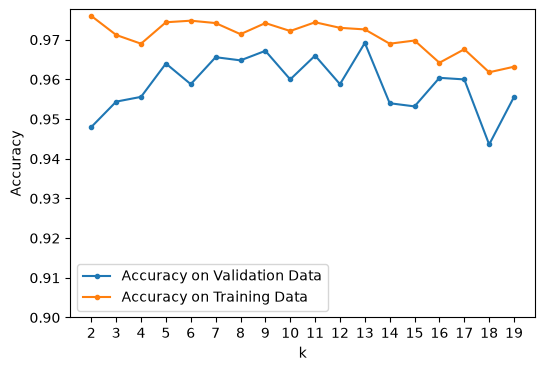

In [41]:
#| fig-align: center
plt.figure(figsize= (6, 4))
accy = np.array(acc)
stds = np.array(std)/np.sqrt(nreps)
print(f'Max validation accuracy at k = {kvals[np.argmax(accy[:, 0])]} with accuracy {np.max(accy[:, 0]):.03f}')
plt.plot(kvals, accy[:, 0], '.-', label = 'Accuracy on Validation Data')
plt.plot(kvals, accy[:, 1], '.-', label = 'Accuracy on Training Data')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.ylim(0.9, None)
plt.xticks(kvals)
plt.legend(loc = 'best')
plt.show()

---

It looks like $k$ = 13 is the best-performing value of the hyperparameter.

Can we be sure?


Be careful! Each point in the above plot is the mean of 50 random train/validation splits!


If we are going to be __sure__ that $k$ = 13 is best, then it should be be statistically distinguishable from the other values.


To make this call, let's plot $\pm 1 \sigma$ confidence intervals on the mean values.

See the [Probability Refresher](A6-Probability-Statistics-Refresher.qmd) for details on the proper formula.


---

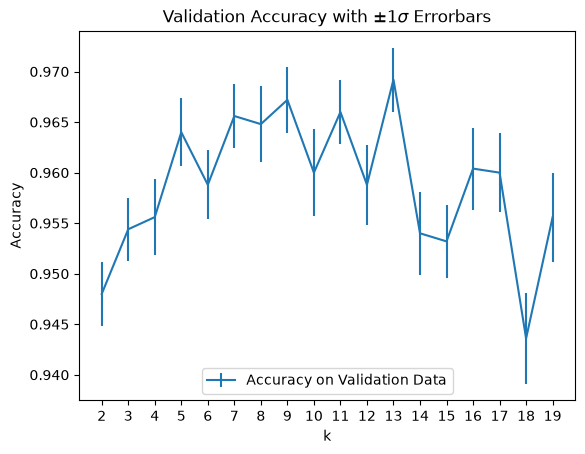

In [42]:
#| fig-align: center
plt.errorbar(kvals, accy[:, 0], stds[:, 0], label = 'Accuracy on Validation Data')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend(loc = 'lower center')
plt.xticks(kvals)
plt.title(r'Validation Accuracy with $\pm 1\sigma$ Errorbars')
plt.show()

---

It looks like $k$ = 13 is a reasonable value, although a case can be made that 9 and 11 are not statistically distinguishable from 13.

To gain insight into the complexity of the model for $k$ = 13, let's look at the decision boundary.

We will re-run the classifier on all 150 flowers using only two (of four) features, so that we can draw it.

---

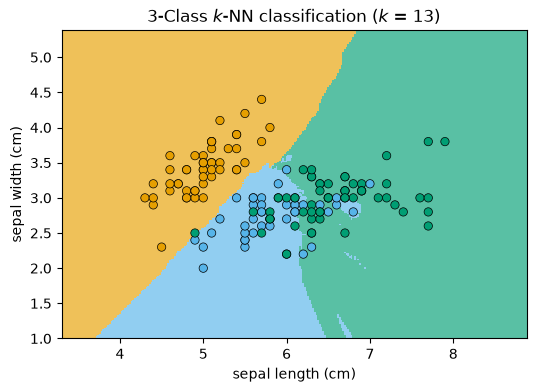

In [43]:
#| fig-align: center
# we will use only the first two (of four) features, so we can visualize
X2 = iris.data[:, :2]
h = .02  # step size in the mesh
k = 13
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X2, y)
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(figsize=(6, 4))
plt.pcolormesh(xx, yy, Z, cmap=cmap3_light, shading='auto')

# Plot also the training points
plt.scatter(X2[:, 0], X2[:, 1], c=y, cmap=cmap3_bold, edgecolors='k', linewidths=0.5)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title(f"3-Class $k$-NN classification ($k$ = {k})")
plt.show()

There are a few artifacts, though overall this looks like a reasonably smooth set of decision boundaries.

## What About the Decision Tree?

The decision tree has its own complexity knob -- how many leaves, or how deep, the tree may grow -- and it is tuned exactly the same way: sweep the setting, score each value on validation data, read the error bars.

[Lecture 08](08-Classification-I-Decision-Trees.qmd#stopping-criteria-minimum-samples-split) did this on the Titanic data, and today's in-class activity runs $k$-NN, Naive Bayes and a decision tree side by side on one dataset.

## Handwritten Digits

Our last dataset is `scikit-learn`'s `load_digits`: 1,797 images of handwritten digits 0--9, each only $8 \times 8$ pixels, from the UCI machine-learning repository.

It is a small, pre-processed cousin of the famous **MNIST** benchmark -- 70,000 images at $28 \times 28$, built by NIST from the handwriting of Census Bureau employees and high-school students -- which has been used for decades to compare classifiers. For a sample of that work see the [MNIST page](http://yann.lecun.com/exdb/mnist/). Everything below would work on MNIST too, just more slowly.

## Loading the Digits

In [44]:
import sklearn.utils as utils

digits = datasets.load_digits()
X, y = utils.shuffle(digits.data, digits.target, random_state = 1)

print ('Data shape: {}'.format(X.shape))
print ('Data labels: {}'.format(y))
print ('Unique labels: {}'.format(digits.target_names))

Data shape: (1797, 64)
Data labels: [1 5 0 ... 9 1 5]
Unique labels: [0 1 2 3 4 5 6 7 8 9]


An individual item is an $8 \times 8$ image, encoded as a matrix:

In [45]:
digits.images[3]

array([[ 0.,  0.,  7., 15., 13.,  1.,  0.,  0.],
       [ 0.,  8., 13.,  6., 15.,  4.,  0.,  0.],
       [ 0.,  2.,  1., 13., 13.,  0.,  0.,  0.],
       [ 0.,  0.,  2., 15., 11.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  1., 12., 12.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1., 10.,  8.,  0.],
       [ 0.,  0.,  8.,  4.,  5., 14.,  9.,  0.],
       [ 0.,  0.,  7., 13., 13.,  9.,  0.,  0.]])

--- 

Here we show the matrix as an image.

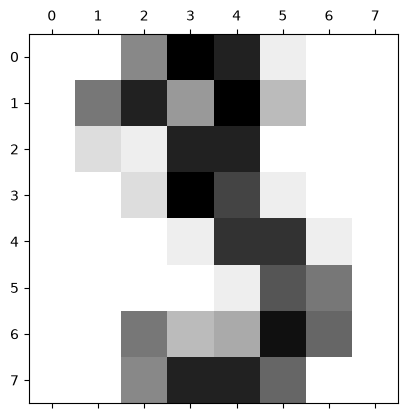

In [46]:
#| fig-align: center
fig, ax = plt.subplots()
ax.matshow(digits.images[3], cmap='gray_r')
plt.show()

---

It is easier to visualize if we blur the pixels a little bit.

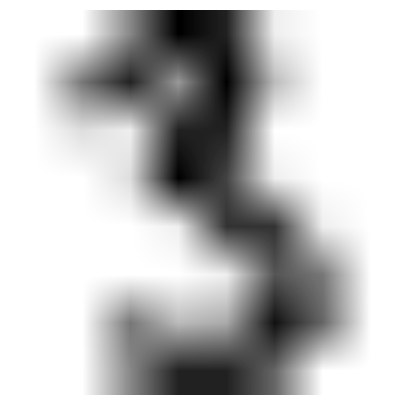

In [47]:
#| fig-align: center
plt.rc('image', cmap = 'binary', interpolation = 'bilinear')
plt.figure(figsize = (5, 5))
plt.axis('off')
plt.imshow(digits.images[3])
plt.show()

---

Here are some more samples from the dataset.

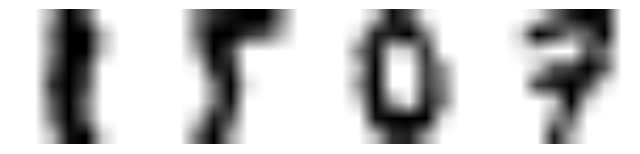

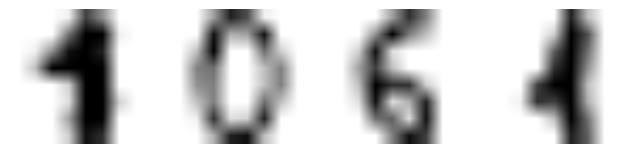

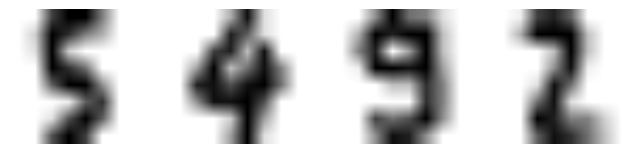

In [48]:
#| fig-align: center
for t in range(3):
    plt.figure(figsize = (8, 2))
    for j in range(4):
        plt.subplot(1, 4, 1 + j)
        plt.imshow(X[4*t + j].reshape(8, 8))
        plt.axis('off')
plt.show()

--- 

Although this is an 8 $\times$ 8 image, we can reshape it to a vector of length 64.

To do model selection, we will again average over many train/validation splits.

However, $k$-NN's **prediction time** grows with the training set: every query is compared with every stored point, so scoring a validation set costs (points scored) $\times$ (training points) distance computations. On a larger dataset we might be tempted to hold out less data to speed this up.

How does the train/validation split affect results?


Let's consider two cases:

1. Train: 90% of data, Validation: 10% of data
2. Train: 67% of data, Validation: 33% of data


---

In [49]:
def sweep_k(kvals, val_fraction, nreps):
    acc = []
    std = []
    np.random.seed(0)
    #
    for k in kvals:
        val_rep = []
        for i in range(nreps):
            X_train, X_val, y_train, y_val = model_selection.train_test_split(
                X, y, test_size = val_fraction)
            knn = KNeighborsClassifier(n_neighbors = k)
            knn.fit(X_train, y_train)
            val_rep.append(knn.score(X_val, y_val))
        acc.append(np.mean(val_rep))
        std.append(np.std(val_rep))
    return(np.array(acc), np.array(std)/np.sqrt(nreps))

val_fraction1 = 0.33
accy1, stds1 = sweep_k(kvals, val_fraction1, 50)
val_fraction2 = 0.10
accy2, stds2 = sweep_k(kvals, val_fraction2, 50)

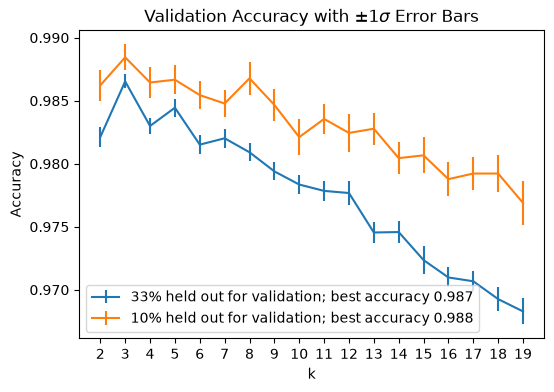

In [50]:
#| fig-align: center
plt.figure(figsize = (6, 4))
plt.errorbar(kvals, accy1, stds1,
             label = f'{val_fraction1:.0%} held out for validation; best accuracy {np.max(accy1):.03f}')
plt.errorbar(kvals, accy2, stds2,
             label = f'{val_fraction2:.0%} held out for validation; best accuracy {np.max(accy2):.03f}')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend(loc = 'best')
plt.xticks(kvals)
plt.title(f'Validation Accuracy with $\\pm 1\\sigma$ Error Bars')
plt.show()

---

These plots illustrate two principles, and the **trade-off** between them.

* With more training data the classifier performs better: the 90/10 curve sits higher.
* With less validation data the accuracy estimate is noisier: the 90/10 error bars are wider (though scoring is faster).

The decision here is which $k$ to choose, so the 67/33 split serves us better: its tighter error bars make the choice trustworthy, even though each individual classifier is a little weaker. Having chosen $k$, we would refit on *all* the data.

---

We can get a sense of why $k$-NN can succeed at this task by looking at the nearest neighbors of some points.

We hold the first three images out as queries and fit on the rest, so that a query cannot be its own nearest neighbour:

In [51]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X[3:], y[3:])
# kneighbors() indexes the fitted data X[3:], so add 3 to index into X
neighbors = knn.kneighbors(X[:3], n_neighbors=3, return_distance=False) + 3
print('Query labels:     ', y[:3])
print('Neighbour labels: ', *y[neighbors])

Query labels:      [1 5 0]
Neighbour labels:  [1 1 1] [5 5 5] [0 0 0]


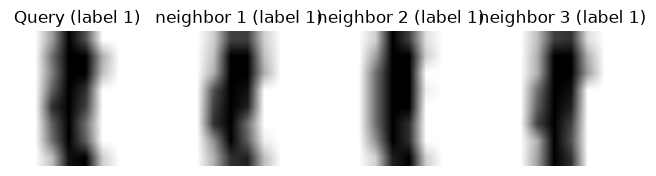

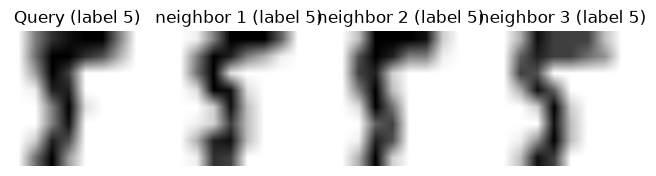

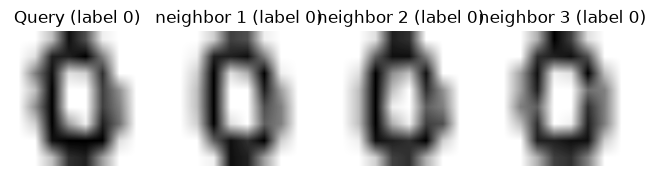

In [52]:
#| fig-align: center
plt.rc("image", cmap="binary")  # this sets a black on white colormap
for t in range(3):
    plt.figure(figsize=(8, 2))
    plt.subplot(1, 4, 1)
    plt.imshow(X[t].reshape(8, 8))
    plt.axis('off')
    plt.title(f"Query (label {y[t]})")
    # plot three nearest neighbors from the training set
    for i in [0, 1, 2]:
        plt.subplot(1, 4, 2 + i)
        plt.title(f"neighbor {i + 1} (label {y[neighbors[t, i]]})")
        plt.imshow(X[neighbors[t, i]].reshape(8, 8))
        plt.axis('off')
plt.show()

# Naive Bayes

$k$-NN classifies by *distance*. We close with a very different -- and equally classic -- way to attack the classification problem: via **probability**.

Given a data point $\mathbf{x}$, we want the label $y$. The key tool is **Bayes' rule**.

## Bayes Rule

Let $A, B$ be events from a sample space $\Omega$. Recall that Bayes' rule states

$$ P(A \vert B) = \frac{P(B\vert A) \cdot P(A)}{P(B)}. $$

This was derived in our [Probability and Statistics Refresher](A6-Probability-Statistics-Refresher.qmd), and we used it in [GMMs](06-Clustering-III-GMM-EM.qmd) to compute the *unknown* $P(A \vert B)$ from *known* $P(B\vert A)$, $P(A)$, and $P(B)$.

## Using Bayes Rule in a Classifier

Let's start with a simple example

> A doctor knows that meningitis causes a stiff neck 75% of the time, i.e., $P(S\vert M) = 0.75$

If a patient comes in with a stiff neck, what is the probability she has meningitis, i.e., what is $P(M\vert S)$?


We only currently know $P(S\vert M)$ so we would need additional information to compute $P(M\vert S)$.


---

If the doctor _also_ knows the following information

* 1 in 20 people in the population have a stiff neck at any given time, i.e., $P(S) = 0.05$
* 1 in 10,000 people in the population have meningitis at any given time, i.e., $P(M) = 0.0001$


Then we can calculate the answer needed

$$ P(M\vert S) = \frac{P(S\vert M)}{P(S)}\cdot P(M)= \frac{0.75}{0.05} \cdot 0.0001 = \fbox{$15 \cdot 1/10000$} = 0.0015. $$


* The random person's probability (1/10000) is the __prior__.
* The specific patient's probability (15 $\cdot$ 1/10000) is the __posterior__: learning "stiff neck" __multiplied__ the probability of meningitis by 15.


## Probabilistic Classification

Now let a data point $\mathbf{x}$ have attributes $x_1, \dots, x_d$ and let the possible classes be $C_1, \dots, C_k$.

Bayes' rule says

$$ P(C_i\vert\mathbf{x}) = \frac{P(\mathbf{x}\vert C_i)}{P(\mathbf{x})} \cdot P(C_i), $$

and since $P(\mathbf{x})$ does not depend on $C_i$, the most probable class (the __MAP__ estimate) is

$$\hat{C} = \arg\max_{C_i} \; P(x_1, \ldots, x_d\vert C_i)\cdot P(C_i).$$

The problem: estimating $P(x_1, \ldots, x_d\vert C_i)$ from data directly is hopeless -- with $d = 20$ features of 10 values each, that is a histogram with $10^{20}$ bins per class.


## The "Naive" Assumption

Naive Bayes __assumes__ the attributes are __conditionally independent__ given the class:

$$ P(x_1, \ldots, x_d\vert C_i) = P(x_1\vert C_i) \cdot P(x_2\vert C_i) \cdots P(x_d\vert C_i). $$

This is *naive* -- features are rarely independent -- but it turns $10^{20}$ bins into $20 \times 10$, and it works surprisingly well in practice.

__Train:__ estimate each $P(x_j\vert C_i)$ and each $P(C_i)$ from the training data (histograms for discrete features; e.g. a Gaussian per class for continuous ones).

__Predict:__ for each class compute $P(C_i)\prod_j P(x_j\vert C_i)$ and return the largest.


## Worked Example

Classify a new taxpayer with __Refund = No, Married__ (ignoring income).

From the table, $P(\text{No}) = 7/10$ and $P(\text{Yes}) = 3/10$, and

$$
\begin{align*}
P(\text{Refund=No}\vert\text{No}) &= 4/7, & P(\text{Married}\vert\text{No}) &= 4/7,\\
P(\text{Refund=No}\vert\text{Yes}) &= 3/3, & P(\text{Married}\vert\text{Yes}) &= 0/3.
\end{align*}
$$

$$
\begin{align*}
\text{Evade=No:}\;& 0.7 \cdot \tfrac{4}{7} \cdot \tfrac{4}{7} \approx 0.23 \\
\text{Evade=Yes:}\;& 0.3 \cdot 1 \cdot 0 = 0
\end{align*}
$$

so we predict __Evade = No__.

![](figs/L16-sample-data.png)


Note the zero: one empty histogram bin wipes out every other factor. A single value never seen with a class *vetoes* that class, however strong the rest of the evidence.


## Laplace Smoothing

The fix is to pretend we saw every value once more than we did: add 1 to each count, and the number of possible values to each denominator.

Marital status has three values and Refund two. For Evade = Yes (3 rows) and Evade = No (7 rows):

$$
\begin{align*}
P(\text{Married}\mid\text{Yes}) &= \tfrac{0+1}{3+3} = \tfrac16, & P(\text{Refund=No}\mid\text{Yes}) &= \tfrac{3+1}{3+2} = \tfrac45,\\
P(\text{Married}\mid\text{No}) &= \tfrac{4+1}{7+3} = \tfrac12, & P(\text{Refund=No}\mid\text{No}) &= \tfrac{4+1}{7+2} = \tfrac59.
\end{align*}
$$

$$
\begin{align*}
\text{Evade=No:}\;& 0.7 \cdot \tfrac{5}{9} \cdot \tfrac{1}{2} \approx 0.19 \\
\text{Evade=Yes:}\;& 0.3 \cdot \tfrac{4}{5} \cdot \tfrac{1}{6} = 0.04
\end{align*}
$$

Still **Evade = No**, but now by a 5-to-1 margin rather than by a veto -- one more piece of evidence for Yes could change the answer, as it should.


## Why Naive Bayes Dodges the Curse

$k$-NN needs the training data to be **dense** in $\mathbb{R}^d$ -- a genuinely close point near every query -- and we saw that this takes exponentially many points.

* Naive Bayes never measures a distance. For each class it estimates $d$ **one-dimensional** histograms (or $d$ one-dimensional Gaussians), one per feature, and every one of them is estimated from *all* $n$ training points.
* So the data it needs grows **linearly** in $d$, not exponentially: 1,000 binary word features in a spam filter need about 1,000 numbers per class, each a simple count.
* The price is the independence assumption. Features are rarely independent, so the probabilities NB reports are usually wrong -- but only the **arg max** has to be right, and in practice it often is.


---

That is Naive Bayes in a nutshell:

* classification via probability and Bayes' rule,
* training is just counting (or fitting a simple density) per feature and class, smoothed so that no count is zero,
* it scales to high dimensions because it estimates $d$ one-dimensional distributions instead of one $d$-dimensional one -- the independence assumption that makes this possible is also its principal weakness.

The full treatment, including continuous features and __Support Vector Machines__, is in [Naive Bayes and SVM](M7-Naive-Bayes-SVM.qmd).
